# Section 4: Feature Selection and Cross-Validation
## 4.1 Imports and Reproducibility Setup
Import modeling tools and set the shared random state used for reproducible splits and stochastic estimators.

**Output.** Defines dependencies and `RANDOM_STATE`.

In [1]:
from pathlib import Path
Path("plots_overleaf").mkdir(exist_ok=True)

import pandas as pd
import numpy as np

import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso, lasso_path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 4.2 Load Cleaned Data
Load the cleaned dataset used for train/test model comparison.

**Output.** Displays dataset dimensions and a preview.

In [2]:
# Load the cleaned dataset (same source as Phase 3)
df = pd.read_csv("merged_data.csv")
df.head()

,realSum,logSum,room_type_apt,room_type_private,room_type_shared,person_capacity,is_superhost,multi,biz,cleanliness_rating,satisfaction_rating,bedrooms,dist,metro_dist,attr_index,rest_index,city,is_weekday
0,194.033698,5.268032,0,1,0,2.0,0,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,98.253896,Amsterdam,1
1,344.245776,5.841356,0,1,0,4.0,0,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,837.280757,Amsterdam,1
2,264.101422,5.576333,0,1,0,2.0,0,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,95.386955,Amsterdam,1
3,433.529398,6.071960,0,1,0,4.0,0,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,875.033098,Amsterdam,1
4,485.552926,6.185288,0,1,0,2.0,1,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,815.305740,Amsterdam,1


## 4.3 Define Features and Split Data
Define predictors and target, then create an 80/20 city-stratified train/test split.

**Output.** Displays split sizes and the city distribution in the training set.

In [3]:
# Define predictors and target.

numeric_cols = [
    "cleanliness_rating",
    "satisfaction_rating",
    "person_capacity", 
    "bedrooms", 
    "dist", 
    "metro_dist",
    "attr_index", 
    "rest_index"]

binary_cols = [
    "room_type_apt", 
    "room_type_private",
    "is_superhost", 
    "multi", 
    "biz", 
    "is_weekday"]

categorical_cols = ["city"]

target_col = "logSum"

raw_feature_cols = numeric_cols + binary_cols + categorical_cols

X = df[raw_feature_cols].copy()
y = df[target_col].copy()

# Train/ Test Split (80/20 and stratified by city)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=df["city"])

split_summary = pd.DataFrame({
    'Split': ['Train', 'Test'],
    'Rows': [X_train_raw.shape[0], X_test_raw.shape[0]],
    'Share': [X_train_raw.shape[0] / len(X), X_test_raw.shape[0] / len(X)],
}).round({'Share': 3})

train_city_distribution = (
    X_train_raw['city']
    .value_counts()
    .sort_index()
    .rename_axis('City')
    .reset_index(name='Training rows')
)

display(split_summary)
display(train_city_distribution)


,Split,Rows,Share
0,Train,40951,0.8
1,Test,10238,0.2


,City,Training rows
0,Amsterdam,1555
1,Athens,4223
2,Barcelona,2250
3,Berlin,1976
4,Budapest,3213
5,Lisbon,4608
6,London,7834
7,Paris,5257
8,Rome,7208
9,Vienna,2827


## 4.4 Training-Only Preprocessing
Fit preprocessing on the training split only, then transform both train and test sets without leakage.

**Output.** Creates named processed matrices for statsmodels and coefficient plots.

In [4]:
# Fit preprocessing on the training split only.
# Keep named DataFrames for statsmodels and coefficient plots.

preprocess = ColumnTransformer(
    transformers=[
        ("scale_numeric", StandardScaler(), numeric_cols),

        ("binary", "passthrough", binary_cols),

        ("city_dummies", OneHotEncoder(
            drop="first", 
            handle_unknown="ignore", 
            sparse_output=False
            ), categorical_cols),
    ],
    remainder="drop",
)

preprocess.fit(X_train_raw)

city_dummy_cols = list(
    preprocess.named_transformers_["city_dummies"].get_feature_names_out(categorical_cols)
)
feature_cols = numeric_cols + binary_cols + city_dummy_cols

X_train_processed = pd.DataFrame(
    preprocess.transform(X_train_raw), columns=feature_cols, index=X_train_raw.index,
)

X_test_processed = pd.DataFrame(
    preprocess.transform(X_test_raw),  columns=feature_cols, index=X_test_raw.index,
)


## 4.5 City Fixed-Effects Training Baseline
Fit the full city fixed-effects OLS model on the training set as the reference model for selection and regularization.

**Output.** Displays fit and prediction metrics.

In [5]:
model_city_fe = sm.OLS(y_train, sm.add_constant(X_train_processed)).fit()

train_preds_fe = model_city_fe.predict(sm.add_constant(X_train_processed))
test_preds_fe  = model_city_fe.predict(sm.add_constant(X_test_processed))
train_rmse_fe  = np.sqrt(np.mean((y_train - train_preds_fe) ** 2))
test_rmse_fe   = np.sqrt(np.mean((y_test  - test_preds_fe)  ** 2))

city_fe_training_summary = pd.DataFrame({
    'Metric': ['Predictors', 'AIC', 'BIC', 'R²', 'Train RMSE', 'Test RMSE'],
    'Value': [
        len(X_train_processed.columns),
        model_city_fe.aic,
        model_city_fe.bic,
        model_city_fe.rsquared,
        train_rmse_fe,
        test_rmse_fe,
    ],
}).set_index('Metric').round(4)

display(city_fe_training_summary)


,Value
Metric,
Predictors,23.0000
AIC,23549.1238
BIC,23756.0070
R²,0.6682
Train RMSE,0.3224
Test RMSE,0.3265


## 4.6 Baseline Coefficient Table
Inspect coefficient estimates for the training-set city fixed-effects model.

**Output.** Displays a coefficient table.

In [6]:
model_city_fe_coef_df = model_city_fe.summary2().tables[1].round(4)
display(model_city_fe_coef_df)


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,5.5428,0.0209,265.2246,0.0000,5.5018,5.5837
cleanliness_rating,0.0369,0.0023,16.0610,0.0000,0.0324,0.0414
satisfaction_rating,0.0066,0.0023,2.8280,0.0047,0.0020,0.0112
person_capacity,0.1150,0.0023,50.3524,0.0000,0.1105,0.1194
bedrooms,0.0759,0.0020,38.1226,0.0000,0.0720,0.0798
dist,-0.0547,0.0028,-19.6036,0.0000,-0.0601,-0.0492
metro_dist,-0.0163,0.0021,-7.8304,0.0000,-0.0203,-0.0122
attr_index,0.0794,0.0032,25.0841,0.0000,0.0732,0.0856
rest_index,0.0555,0.0036,15.2384,0.0000,0.0484,0.0626
room_type_apt,0.8264,0.0190,43.4478,0.0000,0.7891,0.8637


## 4.7 Stepwise Selection Utilities
Define forward and backward stepwise-selection functions using AIC as the selection criterion.

**Output.** Returns selected features, fitted models, and clean trace tables for display and plotting.

In [7]:

def _stepwise_trace_df(steps, criterion):
    """Return a clean display table for stepwise-selection traces."""
    columns = ['Action', 'Feature', criterion.upper(), '# Predictors']
    if not steps:
        return pd.DataFrame(columns=columns)
    return (
        pd.DataFrame(steps, columns=columns)
        .assign(**{criterion.upper(): lambda d: d[criterion.upper()].round(2)})
    )


def backward_stepwise(X_train, y_train, criterion="aic"):
    """
    Backward stepwise selection by AIC (or BIC).
    Starts with all features; drops one at a time while criterion improves.
    """
    features = list(X_train.columns)
    current_model = sm.OLS(y_train, sm.add_constant(X_train[features])).fit()
    current_score = getattr(current_model, criterion)
    steps = []

    while len(features) > 1:
        candidates = {}
        for col in features:
            remaining = [f for f in features if f != col]
            m = sm.OLS(y_train, sm.add_constant(X_train[remaining])).fit()
            candidates[col] = getattr(m, criterion)

        best_drop = min(candidates, key=candidates.get)
        if candidates[best_drop] < current_score:
            current_score = candidates[best_drop]
            features.remove(best_drop)
            steps.append(("drop", best_drop, current_score, len(features)))
        else:
            break

    final = sm.OLS(y_train, sm.add_constant(X_train[features])).fit()
    return features, final, steps


def forward_stepwise(X_train, y_train, candidates, criterion="aic"):
    """
    Forward stepwise selection by AIC (or BIC).
    Starts from intercept only; adds one feature at a time while criterion improves.
    """
    selected = []
    remaining = list(candidates)
    # Intercept-only baseline
    current_model = sm.OLS(y_train, np.ones(len(y_train))).fit()
    current_score = getattr(current_model, criterion)
    steps = []

    while remaining:
        scores = {}
        for col in remaining:
            trial = selected + [col]
            m = sm.OLS(y_train, sm.add_constant(X_train[trial])).fit()
            scores[col] = getattr(m, criterion)

        best_add = min(scores, key=scores.get)
        if scores[best_add] < current_score:
            current_score = scores[best_add]
            selected.append(best_add)
            remaining.remove(best_add)
            steps.append(("add", best_add, current_score, len(selected)))
        else:
            break

    final = sm.OLS(y_train, sm.add_constant(X_train[selected])).fit()
    return selected, final, steps


## 4.8 Backward Stepwise Selection
Start from the full predictor set and remove features only when AIC improves.

**Output.** Displays the backward-selection trace and final selected predictors.

In [8]:
back_features, model_back, back_steps = backward_stepwise(X_train_processed, y_train, criterion="aic")
back_stepwise_df = _stepwise_trace_df(back_steps, "aic")
back_selected_features = pd.DataFrame({'Selected predictor': back_features})

display(back_stepwise_df)
display(back_selected_features)


,Action,Feature,AIC,# Predictors


,Selected predictor
0,cleanliness_rating
1,satisfaction_rating
2,person_capacity
3,bedrooms
4,dist
5,metro_dist
6,attr_index
7,rest_index
8,room_type_apt
9,room_type_private


## 4.9 Backward Selection Summary
Report the number of predictors retained by backward stepwise selection.

**Output.** Displays a compact summary table.

In [9]:
# Backward stepwise selected-feature count
pd.DataFrame({
    'Model': ['Backward stepwise'],
    '# Selected predictors': [len(back_features)],
})


,Model,# Selected predictors
0,Backward stepwise,23


## 4.10 Forward Stepwise Selection
Start from an intercept-only model and add features only when AIC improves.

**Output.** Displays the forward-selection trace and final selected predictors.

In [10]:
fwd_features, model_fwd, fwd_steps = forward_stepwise(X_train_processed, y_train, candidates=X_train_processed.columns, criterion="aic")
fwd_stepwise_df = _stepwise_trace_df(fwd_steps, "aic")
fwd_selected_features = pd.DataFrame({'Selected predictor': fwd_features})

display(fwd_stepwise_df)
display(fwd_selected_features)


,Action,Feature,AIC,# Predictors
0,add,room_type_apt,63871.44,1
1,add,city_Athens,56444.88,2
2,add,city_Budapest,51620.23,3
3,add,city_Rome,47210.36,4
4,add,attr_index,40755.23,5
5,add,person_capacity,36584.51,6
6,add,city_Lisbon,34226.51,7
7,add,city_Vienna,31942.76,8
8,add,bedrooms,30650.16,9
9,add,dist,29290.59,10


,Selected predictor
0,room_type_apt
1,city_Athens
2,city_Budapest
3,city_Rome
4,attr_index
5,person_capacity
6,city_Lisbon
7,city_Vienna
8,bedrooms
9,dist


## 4.11 Forward Selection Summary
Report the number of predictors retained by forward stepwise selection.

**Output.** Displays a compact summary table.

In [11]:
# Forward stepwise selected-feature count
pd.DataFrame({
    'Model': ['Forward stepwise'],
    '# Selected predictors': [len(fwd_features)],
})


,Model,# Selected predictors
0,Forward stepwise,23


## 4.12 Forward AIC Progression
Visualize how AIC changes as predictors enter the forward-selection model.

**Output.** Saves the stepwise AIC progression plot.

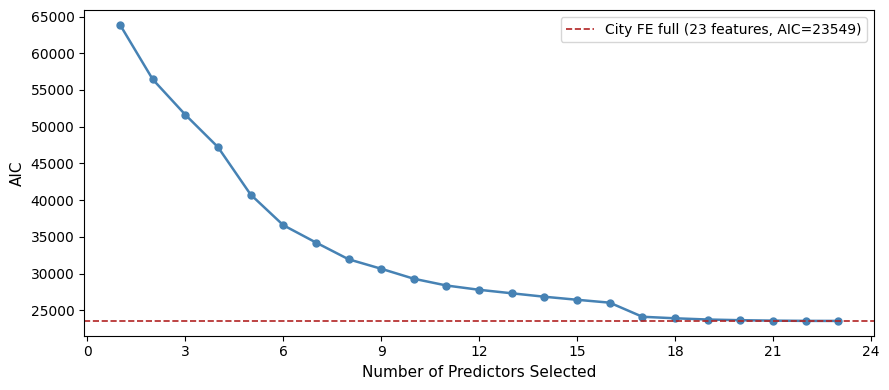

In [12]:
if fwd_steps:
    steps_n   = [s[3] for s in fwd_steps]
    steps_aic = [s[2] for s in fwd_steps]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(steps_n, steps_aic, marker="o", color="steelblue", linewidth=1.8, markersize=5)
    ax.axhline(
        model_city_fe.aic, 
        color="firebrick", 
        linestyle="--", 
        linewidth=1.2,
        label=f"City FE full ({len(X_train_processed.columns)} features, AIC={model_city_fe.aic:.0f})"
        )
    ax.set_xlabel("Number of Predictors Selected", fontsize=11)
    ax.set_ylabel("AIC", fontsize=11)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig("plots_overleaf/App6_3_ForwardSelectionAIC.png", dpi=300, bbox_inches="tight")
    plt.show()


## 4.13 Cross-Validation Pipeline Helper
Build leakage-safe sklearn pipelines for cross-validation and hyperparameter tuning.

**Output.** Defines a reusable helper for Ridge, LASSO, and comparison models.

In [13]:
# Build leakage-safe CV pipelines.
# Preprocessing is refit inside each fold.

def _make_cv_pipe(estimator, use_city):
    transformers = []

    transformers += [
        ("scale_numeric", StandardScaler(), numeric_cols),
        ("binary",        "passthrough",    binary_cols),
    ]

    if use_city:
        transformers.append((
            "city_dummies",
            OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
            categorical_cols,
        ))

    raw_cols = numeric_cols + binary_cols + (categorical_cols if use_city else [])
    
    X_cv = X_train_raw[raw_cols].copy()
    
    pipe = Pipeline([
        ("prep",  ColumnTransformer(transformers, remainder="drop")),
        ("model", estimator),
    ])

    return X_cv, pipe


## 4.14 Ridge Regression Tuning
Tune the Ridge penalty strength with cross-validation and evaluate the selected model.

**Output.** Displays the optimal penalty and RMSE metrics.

In [14]:
# Tune Ridge regularization with leakage-safe 10-fold CV.

# Search λ from 0.001 to 10,000.
alphas = np.logspace(-3, 4, 500)

X_ridge_cv, ridge_pipe = _make_cv_pipe(Ridge(), use_city=True)

ridge_cv = GridSearchCV(
    ridge_pipe,
    param_grid={"model__alpha": alphas},
    cv=10,
    scoring="neg_mean_squared_error",
)

ridge_cv.fit(X_ridge_cv, y_train)

best_alpha = ridge_cv.best_params_["model__alpha"]
cv_rmse_ridge = np.sqrt(-ridge_cv.best_score_)

# Refit Ridge at the selected λ for coefficients and plots.
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train_processed, y_train)

train_pred_ridge = ridge_best.predict(X_train_processed)
test_pred_ridge  = ridge_best.predict(X_test_processed)
train_rmse_ridge = np.sqrt(np.mean((y_train - train_pred_ridge) ** 2))
test_rmse_ridge  = np.sqrt(np.mean((y_test  - test_pred_ridge)  ** 2))

ridge_summary = pd.DataFrame({
    'Metric': ['Optimal λ', 'CV-RMSE', 'Train RMSE', 'Test RMSE'],
    'Value': [best_alpha, cv_rmse_ridge, train_rmse_ridge, test_rmse_ridge],
}).set_index('Metric').round(6)

display(ridge_summary)


,Value
Metric,
Optimal λ,0.002999
CV-RMSE,0.322630
Train RMSE,0.322389
Test RMSE,0.326503


## 4.15 Ridge Coefficient Comparison
Compare full OLS and Ridge coefficients to quantify L2 shrinkage.

**Output.** Displays a coefficient-comparison table.

In [15]:
# Coefficient comparison: OLS vs Ridge
ols_coefs = model_city_fe.params.drop("const")
coef_comparison = pd.DataFrame({
    "Full OLS":   ols_coefs.values,
    "Full Ridge": ridge_best.coef_,
}, index=X_train_processed.columns)
coef_comparison["L2 Shrinkage"] = ((coef_comparison["Full OLS"] - coef_comparison["Full Ridge"]).abs()).round(6)
coef_comparison


,Full OLS,Full Ridge,L2 Shrinkage
cleanliness_rating,0.036913,0.036913,0.000000
satisfaction_rating,0.006627,0.006627,0.000000
person_capacity,0.114951,0.114950,0.000000
bedrooms,0.075935,0.075935,0.000000
dist,-0.054671,-0.054671,0.000001
metro_dist,-0.016253,-0.016253,0.000001
attr_index,0.079369,0.079370,0.000001
rest_index,0.055498,0.055497,0.000001
room_type_apt,0.826413,0.826399,0.000013
room_type_private,0.408385,0.408372,0.000013


## 4.16 Ridge Coefficient Paths
Show how Ridge coefficients change as the penalty strength varies.

**Output.** Saves the Ridge coefficient-path plot.

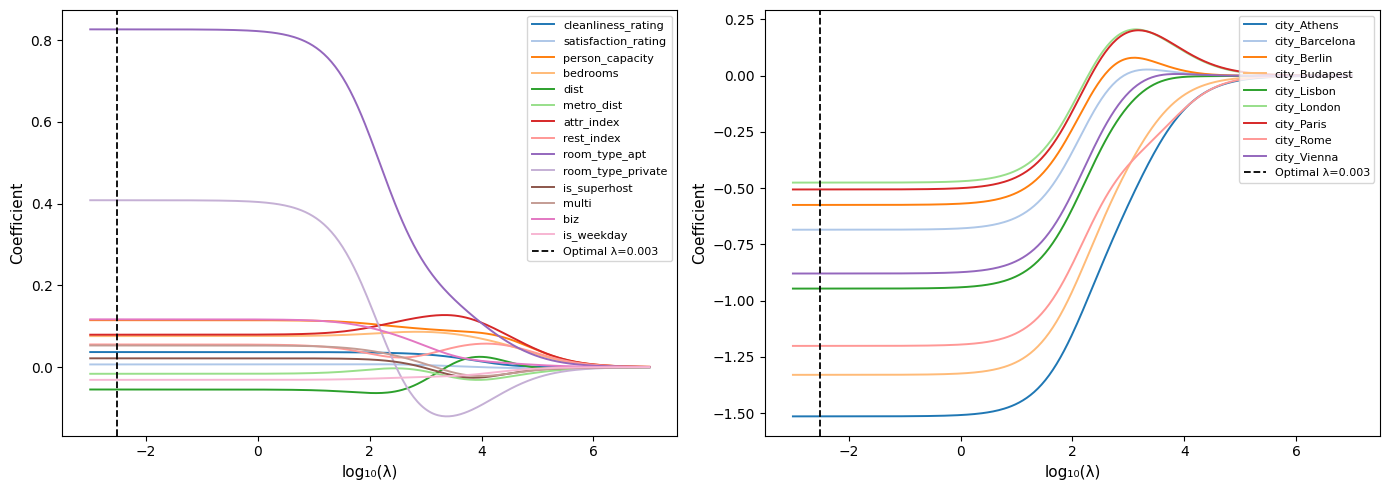

In [16]:
alphas_path = np.logspace(-3, 7, 300)
coefs_path  = np.array([
    Ridge(alpha=a).fit(X_train_processed, y_train).coef_
    for a in alphas_path
])

# Separate structural terms and city effects for readability.
structural = [c for c in X_train_processed.columns if not c.startswith("city_")]
city_cols   = [c for c in X_train_processed.columns if c.startswith("city_")]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, group, title in zip(
    axes,
    [structural, city_cols],
    ["Structural Predictors", "City Fixed Effects"],
):
    idxs = [X_train_processed.columns.get_loc(c) for c in group]
    colors = [plt.cm.tab20(i) for i in range(len(group))]
    for (j, col), color in zip(zip(idxs, group), colors):
        ax.plot(np.log10(alphas_path), coefs_path[:, j], linewidth=1.4, label=col, color=color)
    ax.axvline(np.log10(best_alpha), color="black", linestyle="--", linewidth=1.3, label=f"Optimal λ={best_alpha:.3f}")
    ax.set_xlabel("log₁₀(λ)", fontsize=11)
    ax.set_ylabel("Coefficient", fontsize=11)
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("plots_overleaf/App6_4_RidgeCoefficientPath.png", dpi=300, bbox_inches="tight")
plt.show()


## 4.17 Ridge Cross-Validation Curve
Plot mean cross-validated RMSE across Ridge penalty values.

**Output.** Saves the Ridge CV error curve.

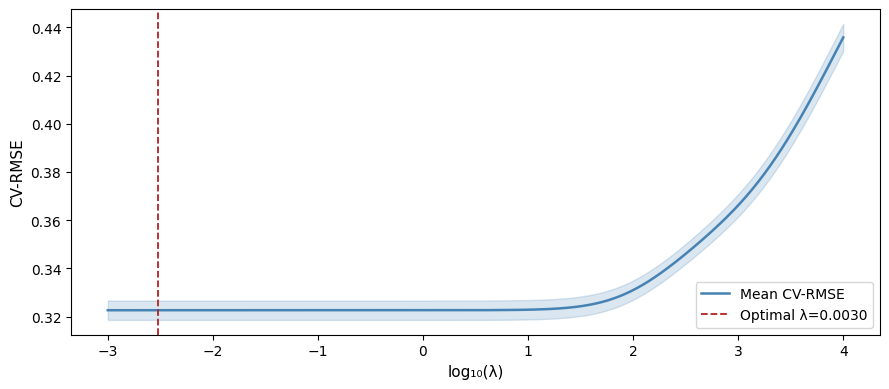

In [17]:
ridge_cv_results = pd.DataFrame(ridge_cv.cv_results_).sort_values("param_model__alpha")
ridge_cv_alphas  = ridge_cv_results["param_model__alpha"].astype(float).to_numpy()
mean_cv_rmse_ridge = np.sqrt(-ridge_cv_results["mean_test_score"].to_numpy())
std_cv_rmse_ridge  = ridge_cv_results["std_test_score"].to_numpy() / (2 * mean_cv_rmse_ridge)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.log10(ridge_cv_alphas), mean_cv_rmse_ridge,
        color="steelblue", linewidth=1.8, label="Mean CV-RMSE")
ax.fill_between(
    np.log10(ridge_cv_alphas),
    mean_cv_rmse_ridge - std_cv_rmse_ridge,
    mean_cv_rmse_ridge + std_cv_rmse_ridge,
    alpha=0.2, color="steelblue",
)
ax.axvline(np.log10(best_alpha), color="firebrick", linestyle="--", linewidth=1.3,
           label=f"Optimal λ={best_alpha:.4f}")
ax.set_xlabel("log₁₀(λ)", fontsize=11)
ax.set_ylabel("CV-RMSE", fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("plots_overleaf/App6_4_RidgeCVCurve.png", dpi=300, bbox_inches="tight")
plt.show()


## 4.18 LASSO Regression Tuning
Tune the LASSO penalty strength with cross-validation and evaluate sparsity and prediction performance.

**Output.** Displays the optimal penalty, coefficient sparsity, and RMSE metrics.

In [18]:
# Tune LASSO regularization with leakage-safe 10-fold CV.

lasso_alphas = np.logspace(-4, 1, 500)

X_lasso_cv, lasso_pipe = _make_cv_pipe(
    Lasso(max_iter=20000, random_state=RANDOM_STATE), use_city=True,
)

lasso_cv = GridSearchCV(
    lasso_pipe,
    param_grid={"model__alpha": lasso_alphas},
    cv=10,
    scoring="neg_mean_squared_error",
)
lasso_cv.fit(X_lasso_cv, y_train)

best_lasso_alpha = lasso_cv.best_params_["model__alpha"]
cv_rmse_lasso    = np.sqrt(-lasso_cv.best_score_)

# Refit LASSO at the selected λ for coefficients and plots.
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=20000, random_state=RANDOM_STATE)
lasso_best.fit(X_train_processed, y_train)

train_pred_lasso = lasso_best.predict(X_train_processed)
test_pred_lasso  = lasso_best.predict(X_test_processed)
train_rmse_lasso = np.sqrt(np.mean((y_train - train_pred_lasso) ** 2))
test_rmse_lasso  = np.sqrt(np.mean((y_test  - test_pred_lasso)  ** 2))

n_nonzero = int(np.sum(lasso_best.coef_ != 0))
lasso_summary = pd.DataFrame({
    'Metric': ['Optimal λ', 'CV-RMSE', 'Non-zero coefficients', 'Zeroed coefficients', 'Train RMSE', 'Test RMSE'],
    'Value': [
        best_lasso_alpha,
        cv_rmse_lasso,
        n_nonzero,
        X_train_processed.shape[1] - n_nonzero,
        train_rmse_lasso,
        test_rmse_lasso,
    ],
}).set_index('Metric').round(6)

display(lasso_summary)


,Value
Metric,
Optimal λ,0.000100
CV-RMSE,0.322679
Non-zero coefficients,23.000000
Zeroed coefficients,0.000000
Train RMSE,0.322437
Test RMSE,0.326589


## 4.19 LASSO Coefficient Comparison
Add LASSO coefficients to the OLS/Ridge comparison to quantify L1 shrinkage.

**Output.** Displays the updated coefficient-comparison table.

In [19]:
# Coefficient table: OLS vs Ridge vs LASSO
coef_comparison["Full Lasso"] = lasso_best.coef_
coef_comparison["L1 Shrinkage"] = ((coef_comparison["Full OLS"] - coef_comparison["Full Lasso"]).abs()).round(6)
coef_comparison


,Full OLS,Full Ridge,L2 Shrinkage,Full Lasso,L1 Shrinkage
cleanliness_rating,0.036913,0.036913,0.000000,0.036888,0.000025
satisfaction_rating,0.006627,0.006627,0.000000,0.006585,0.000041
person_capacity,0.114951,0.114950,0.000000,0.114187,0.000764
bedrooms,0.075935,0.075935,0.000000,0.076343,0.000408
dist,-0.054671,-0.054671,0.000001,-0.056003,0.001333
metro_dist,-0.016253,-0.016253,0.000001,-0.015168,0.001085
attr_index,0.079369,0.079370,0.000001,0.080582,0.001213
rest_index,0.055498,0.055497,0.000001,0.053355,0.002143
room_type_apt,0.826413,0.826399,0.000013,0.797550,0.028863
room_type_private,0.408385,0.408372,0.000013,0.379437,0.028948


## 4.20 LASSO Coefficient Paths
Show how LASSO coefficients enter or leave the model as the penalty changes.

**Output.** Saves the LASSO coefficient-path plot.

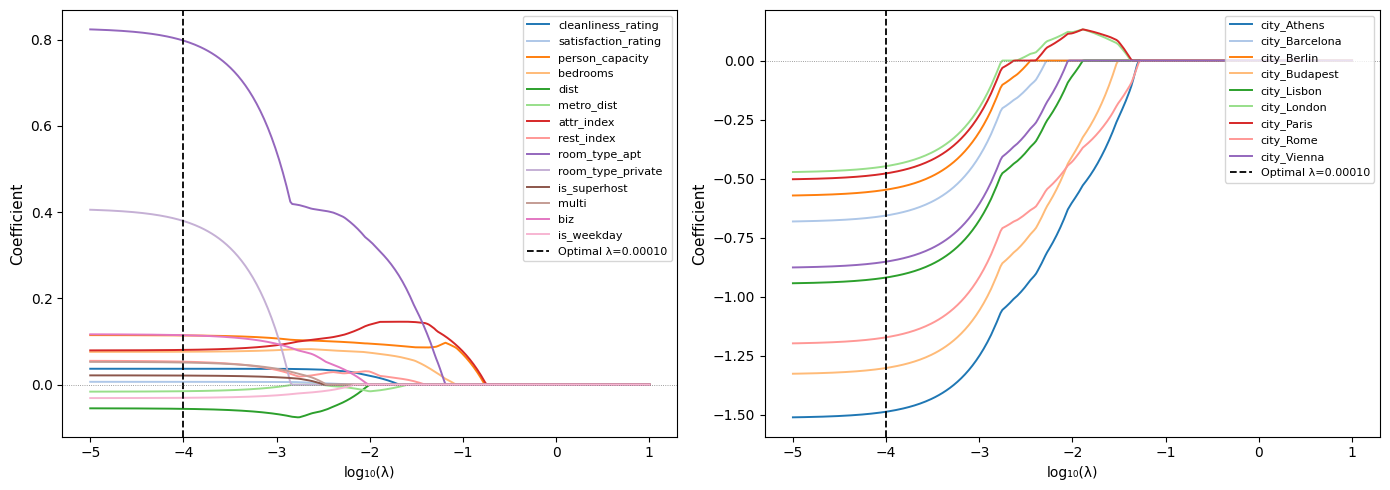

In [20]:
# Center data because lasso_path has no fit_intercept option.
_X_path = X_train_processed.to_numpy()
_X_path_mean = _X_path.mean(axis=0)
_y_path_mean = y_train.mean()
alphas_lasso, coefs_lasso, _ = lasso_path(
    _X_path - _X_path_mean, y_train - _y_path_mean,
    alphas=np.logspace(-5, 1, 300),
    max_iter=20000,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, group, title in zip(
    axes,
    [structural, city_cols],
    ["Structural Predictors", "City Fixed Effects"],
):
    idxs = [X_train_processed.columns.get_loc(c) for c in group]
    colors = [plt.cm.tab20(i) for i in range(len(group))]
    for (j, col), color in zip(zip(idxs, group), colors):
        ax.plot(np.log10(alphas_lasso), coefs_lasso[j], linewidth=1.4, label=col, color=color)
    ax.axvline(np.log10(best_lasso_alpha), color="black", linestyle="--", linewidth=1.3, label=f"Optimal λ={best_lasso_alpha:.5f}")
    ax.axhline(0, color="gray", linewidth=0.6, linestyle=":")
    ax.set_xlabel("log₁₀(λ)", fontsize=10)
    ax.set_ylabel("Coefficient", fontsize=11)
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig("plots_overleaf/App6_4_LASSOCoefficientPath.png", dpi=300, bbox_inches="tight")
plt.show()


## 4.21 LASSO Cross-Validation Curve
Plot mean cross-validated RMSE across LASSO penalty values.

**Output.** Saves the LASSO CV error curve.

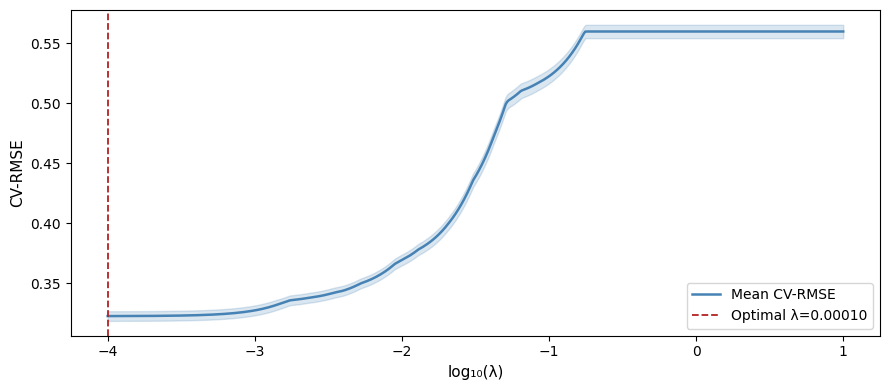

In [21]:
cv_results = pd.DataFrame(lasso_cv.cv_results_).sort_values("param_model__alpha")
cv_alphas = cv_results["param_model__alpha"].astype(float).to_numpy()
mean_cv_rmse = np.sqrt(-cv_results["mean_test_score"].to_numpy())
std_cv_rmse = cv_results["std_test_score"].to_numpy() / (2 * mean_cv_rmse)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.log10(cv_alphas), mean_cv_rmse,
        color="steelblue", linewidth=1.8, label="Mean CV-RMSE")
ax.fill_between(
    np.log10(cv_alphas),
    mean_cv_rmse - std_cv_rmse,
    mean_cv_rmse + std_cv_rmse,
    alpha=0.2, color="steelblue",
)
ax.axvline(np.log10(best_lasso_alpha), color="firebrick", linestyle="--", linewidth=1.3, label=f"Optimal λ={best_lasso_alpha:.5f}")
ax.set_xlabel("log₁₀(λ)", fontsize=11)
ax.set_ylabel("CV-RMSE", fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("plots_overleaf/App6_4_LASSOCVCurve.png", dpi=300, bbox_inches="tight")
plt.show()


## 4.22 Final Linear Model Comparison
Compare naive OLS, city fixed-effects OLS, Ridge, and LASSO using CV-RMSE, train/test RMSE, and test R-squared.

**Output.** Displays the comparison table.

In [22]:
# Naive OLS re-fit on the training set; City FE OLS already fit in Part 2.

naive_cols = numeric_cols + binary_cols

model_naive_tr = sm.OLS(y_train, sm.add_constant(X_train_processed[naive_cols])).fit()

def _ols_preds(model, X_subset):
    return model.predict(sm.add_constant(X_subset, has_constant="add"))

def _test_r2(y_te, preds):
    ss_res = np.sum((y_te - preds) ** 2)
    ss_tot = np.sum((y_te - y_te.mean()) ** 2)
    return 1 - ss_res / ss_tot

def _cv_rmse(estimator, cols, y_tr, cv=10):
    use_city = any(c.startswith("city_") for c in cols)
    X_cv, pipe = _make_cv_pipe(estimator, use_city=use_city)
    scores = cross_val_score(pipe, X_cv, y_tr, cv=cv, scoring="neg_mean_squared_error")
    return float(np.sqrt(-scores.mean()))

summary = {}

for label, cols, model in [
    ("Naive OLS",   naive_cols,   model_naive_tr),
    ("City FE OLS", feature_cols, model_city_fe),
]:
    preds = _ols_preds(model, X_test_processed[cols])
    summary[label] = {
        "# Predictors": len(cols),
        "CV-RMSE":    round(_cv_rmse(LinearRegression(), cols, y_train), 4),
        "Train RMSE": round(float(np.sqrt(np.mean((y_train - _ols_preds(model, X_train_processed[cols])) ** 2))), 4),
        "Test RMSE":  round(float(np.sqrt(np.mean((y_test  - preds) ** 2))), 4),
        "Test R²":    round(float(_test_r2(y_test, preds)), 4),
    }

for label, model, cv_estimator in [
    ("Ridge", ridge_best, Ridge(alpha=best_alpha)),
    ("LASSO", lasso_best, Lasso(alpha=best_lasso_alpha, max_iter=20000, random_state=RANDOM_STATE)),
]:
    tr_pred = model.predict(X_train_processed)
    te_pred = model.predict(X_test_processed)
    summary[label] = {
        "# Predictors": int(np.sum(model.coef_ != 0)),
        "CV-RMSE":    round(_cv_rmse(cv_estimator, feature_cols, y_train), 4),
        "Train RMSE": round(float(np.sqrt(np.mean((y_train - tr_pred) ** 2))), 4),
        "Test RMSE":  round(float(np.sqrt(np.mean((y_test  - te_pred) ** 2))), 4),
        "Test R²":    round(float(_test_r2(y_test, te_pred)), 4),
    }

summary_df = pd.DataFrame(summary).T
summary_df


,# Predictors,CV-RMSE,Train RMSE,Test RMSE,Test R²
Naive OLS,14.0,0.4735,0.4732,0.4737,0.2908
City FE OLS,23.0,0.3226,0.3224,0.3265,0.6631
Ridge,23.0,0.3226,0.3224,0.3265,0.6631
LASSO,23.0,0.3227,0.3224,0.3266,0.6629


## 4.23 Linear Model Comparison Plot
Visualize CV-RMSE, test RMSE, and test R-squared for the final linear-model set.

**Output.** Saves the model-comparison plot.

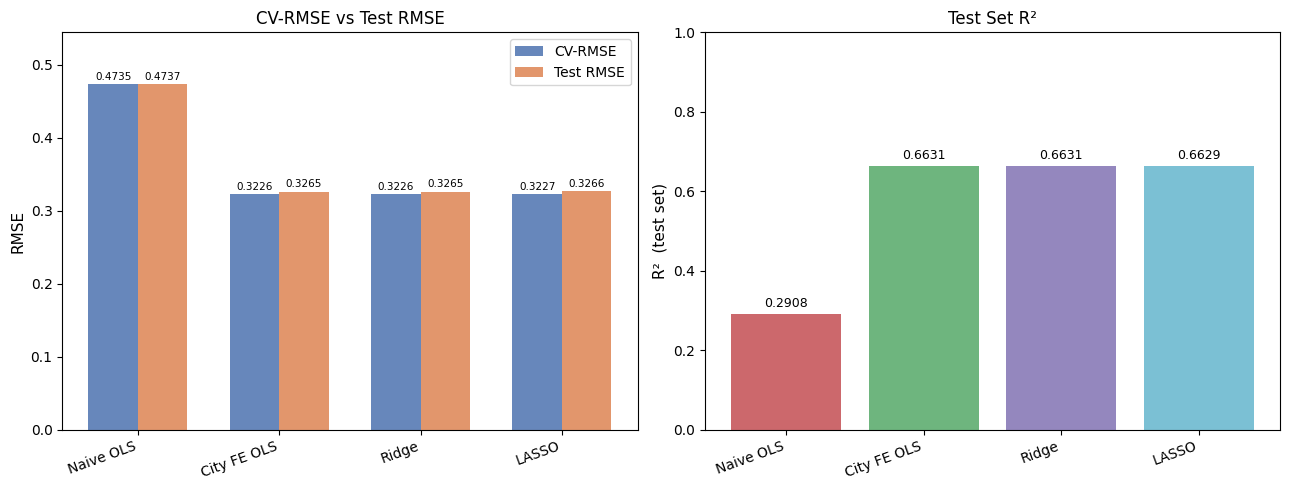

In [23]:
model_labels = list(summary_df.index)
x = np.arange(len(model_labels))
width = 0.35

colors_cv   = ["#4c72b0"] * len(model_labels)
colors_test = ["#dd8452"] * len(model_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: grouped bar — CV-RMSE vs Test RMSE
ax = axes[0]
bars1 = ax.bar(x - width / 2, summary_df["CV-RMSE"],   width, label="CV-RMSE",   color=colors_cv,   alpha=0.85)
bars2 = ax.bar(x + width / 2, summary_df["Test RMSE"],  width, label="Test RMSE",  color=colors_test, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("RMSE", fontsize=11)
ax.set_title("CV-RMSE vs Test RMSE", fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, summary_df[["CV-RMSE", "Test RMSE"]].values.max() * 1.15)
for bar in [*bars1, *bars2]:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=7.5)

# Right: Test R²
ax2 = axes[1]
r2_color_map = {
    "Naive OLS": "#c44e52",
    "City FE OLS": "#55a868",
    "Ridge": "#8172b3",
    "LASSO": "#64b5cd",
}
bar_colors = [r2_color_map[label] for label in model_labels]
bars3 = ax2.bar(x, summary_df["Test R²"], color=bar_colors, alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(model_labels, rotation=20, ha="right", fontsize=10)
ax2.set_ylabel("R²  (test set)", fontsize=11)
ax2.set_title("Test Set R²", fontsize=12)
ax2.set_ylim(0, 1.0)
for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("plots_overleaf/7_0_LinearModelComparison.png", dpi=300, bbox_inches="tight")
plt.show()
